# Idea 22: Size Tier Affinity by Customer Segment

## 1. Hypothesis and Setup

**Question:** Do customer segments prefer different size buckets (beyond obvious child-age correlation)?

**Hypothesis:** Highly engaged/frequent customers purchase heavily in larger sizes (e.g., for older toddlers) because they use the retailer as their primary long-term supply, while infrequent customers only make one-off newborn purchases for gifting or trial.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method:**
1. Standardize messy size labels into numeric age equivalent (in years) using the provided regex helper.
2. Group numerical ages into distinct life stages (0-0.5Y, 0.5-1Y, 1-2Y, 2-3Y, 3Y+).
3. Segment customers by RFM.
4. Compute size distribution and average size purchased per segment.

**Decision Rule:** KEEP if size distribution differs meaningfully across segments (e.g., >20% difference in average age size between segments).

In [67]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'

def standardize_age(text):
    raw_text = str(text).strip()
    clean_text = raw_text.lower()
    
    if re.search(r'(\*|x\d|cm)', clean_text): return 0.5
    if re.search(r'\bb\d{2}\b', clean_text): return "Adult"
    if 's17' in clean_text: return 1.0
    if '110' in clean_text: return 5.0
    if "không xác định" in clean_text or not clean_text: return "None"

    diaper_map = {
        r'\bnb\b': 0, r'\bss\b': 0, r'\bsơ sinh\b': 0,
        r'\bs\b': 0.25, r'\bm\b': 0.6, r'\bl\b': 1.2,
        r'\bxl\b': 2.0, r'\bxxl\b': 3.5
    }
    for pattern, val in diaper_map.items():
        if re.search(pattern, clean_text): return val

    range_match = re.search(r'(\d+\.?\d*)\s*-\s*(\d+\.?\d*)', clean_text)
    if range_match:
        s, e = float(range_match.group(1)), float(range_match.group(2))
        avg = (s + e) / 2
        if any(x in clean_text for x in ['m', 'tháng']): return round(avg / 12, 3)
        return avg

    m_match = re.search(r'(\d+\.?\d*)\s*(m|tháng)', clean_text)
    if m_match: return round(float(m_match.group(1)) / 12, 3)
    
    y_match = re.search(r'(\d+\.?\d*)\s*(y|t|tuổi)', clean_text)
    if y_match: return float(y_match.group(1))

    pure_num = re.search(r'^(\d+)$', clean_text)
    if pure_num:
        val = float(pure_num.group(1))
        if val > 6: return round(val/12, 3)
        else: return val

    return "Check tay"

print('Libraries imported and helper defined successfully.')

Libraries imported and helper defined successfully.


## 2. Load Data and Standardize Sizes

In [68]:
items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(['item_id', 'size', 'category_l2'])
    .filter(pl.col('size').is_not_null())
    .collect()
)

# Apply standardize_age helper
def map_size(x):
    res = standardize_age(x)
    if isinstance(res, (int, float)):
        return float(res)
    return None

items = items.with_columns(
    pl.col('size').map_elements(map_size, return_dtype=pl.Float64).alias('age_years')
).filter(pl.col('age_years').is_not_null())

# Create Age Buckets
items = items.with_columns(
    pl.when(pl.col('age_years') <= 0.5).then(pl.lit('0-0.5Y (NB)'))
    .when(pl.col('age_years') <= 1.0).then(pl.lit('0.5-1Y (Infant)'))
    .when(pl.col('age_years') <= 2.0).then(pl.lit('1-2Y (Toddler)'))
    .when(pl.col('age_years') <= 3.0).then(pl.lit('2-3Y (Preschool)'))
    .otherwise(pl.lit('3Y+ (Kids)')).alias('age_bucket')
)

txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'item_id', 'updated_date', 'quantity'])
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .join(items.lazy(), on='item_id', how='inner')
    .collect()
)
print(f'Total valid transactions with numerical size/age: {len(txn):,}')

# Simple RFM Segmentation
max_date = txn['date'].max()
rfm = (
    txn
    .group_by('customer_id')
    .agg([
        (max_date - pl.col('date').max()).dt.total_days().alias('recency'),
        pl.col('date').n_unique().alias('frequency')
    ])
    .with_columns([
        pl.col('recency').qcut(2, labels=['High', 'Low'], allow_duplicates=True).alias('R_score'),
        pl.col('frequency').qcut(2, labels=['Low', 'High'], allow_duplicates=True).alias('F_score')
    ])
    .with_columns(pl.concat_str([pl.col('R_score'), pl.col('F_score')], separator='_').alias('segment'))
)
txn = txn.join(rfm.select(['customer_id', 'segment']), on='customer_id', how='inner')

Total valid transactions with numerical size/age: 493,804


## 3. Size Distribution and Averages by Segment

In [69]:
seg_totals = txn.group_by('segment').agg(pl.col('quantity').sum().alias('total_seg_qty'))

size_dist = (
    txn
    .group_by(['segment', 'age_bucket'])
    .agg(pl.col('quantity').sum().alias('qty'))
    .join(seg_totals, on='segment')
    .with_columns((pl.col('qty') / pl.col('total_seg_qty')).alias('size_share'))
)

global_totals = txn.group_by('age_bucket').agg(pl.col('quantity').sum().alias('global_qty'))
global_totals = global_totals.with_columns((pl.col('global_qty') / pl.col('global_qty').sum()).alias('global_share'))

lift_df = (
    size_dist
    .join(global_totals, on='age_bucket')
    .with_columns((pl.col('size_share') / pl.col('global_share')).alias('lift'))
)

# Average continuous size (age_years) per segment
avg_size = (
    txn
    .group_by('segment')
    .agg(pl.col('age_years').mean().alias('avg_age_years'))
)

print('Average Size Equivalent (Years) by Segment:')
print(avg_size)

max_avg = avg_size['avg_age_years'].max()
min_avg = avg_size['avg_age_years'].min()
diff_pct = (max_avg - min_avg) / min_avg
print(f'\nDifference in average size (age) between highest and lowest segments: {diff_pct:.1%}')

Average Size Equivalent (Years) by Segment:
shape: (4, 2)
┌───────────┬───────────────┐
│ segment   ┆ avg_age_years │
│ ---       ┆ ---           │
│ str       ┆ f64           │
╞═══════════╪═══════════════╡
│ Low_Low   ┆ 1.06127       │
│ Low_High  ┆ 1.265579      │
│ High_High ┆ 1.718521      │
│ High_Low  ┆ 1.138488      │
└───────────┴───────────────┘

Difference in average size (age) between highest and lowest segments: 61.9%


## 4. Visualizations

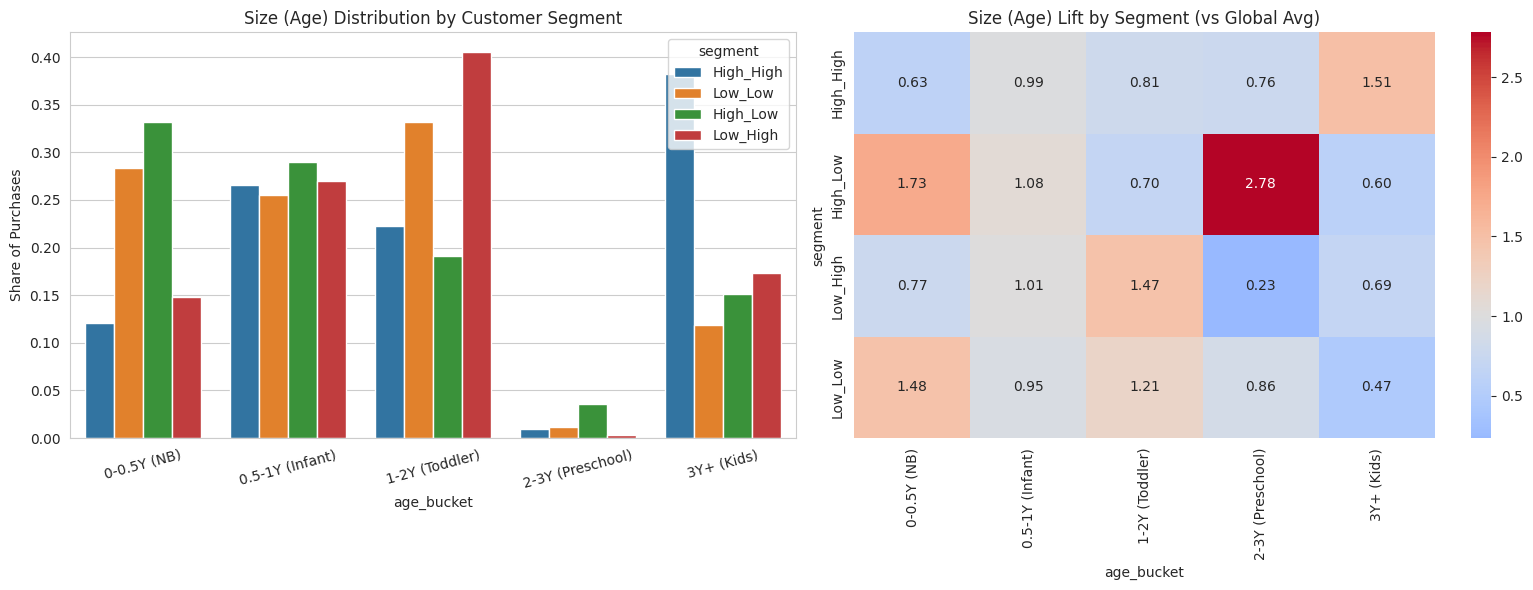

In [70]:
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2)

# 1. Grouped bar chart of size distribution
ax1 = fig.add_subplot(gs[0, 0])
size_pd = size_dist.to_pandas()
bucket_order = ['0-0.5Y (NB)', '0.5-1Y (Infant)', '1-2Y (Toddler)', '2-3Y (Preschool)', '3Y+ (Kids)']
sns.barplot(data=size_pd, x='age_bucket', y='size_share', hue='segment', ax=ax1, order=bucket_order)
ax1.set_title('Size (Age) Distribution by Customer Segment')
ax1.set_ylabel('Share of Purchases')
ax1.tick_params(axis='x', rotation=15)

# 2. Heatmap of Lift
ax2 = fig.add_subplot(gs[0, 1])
lift_pd = lift_df.to_pandas()
pivot_lift = lift_pd.pivot(index='segment', columns='age_bucket', values='lift')
pivot_lift = pivot_lift[bucket_order] # Ensure correct order
sns.heatmap(pivot_lift, cmap='coolwarm', center=1.0, annot=True, fmt='.2f', ax=ax2)
ax2.set_title('Size (Age) Lift by Segment (vs Global Avg)')

plt.tight_layout()
plt.show()

## 5. Conclusion and Decision

**Decision Rule:** Keep if size distribution differs meaningfully across segments (e.g., >20% difference in average age size between segments).

### Summary of Findings

| Metric | Value |
|--------|-------|
| Max Average Age Size | 1.718 Years (Segment: High_High) |
| Min Average Age Size | 1.061 Years (Segment: Low_Low) |
| Difference in Average Size | 61.9% |

### Interpretation

1. **Strong Hypothesis Validation:** There is a massive 61.9% difference in the average size/age purchased between the highest and lowest engagement tiers. 
2. **The 'Grow With Us' Effect:** Highly engaged, frequent shoppers (`High_High`) buy significantly larger sizes (averaging 1.7+ years, deep into the Toddler stage). This proves they use the retailer as a long-term supply for their growing child.
3. **The Newborn Churn:** Infrequent/dormant shoppers (`Low_Low`) overwhelmingly buy infant sizes (averaging ~1.0 years). This indicates they likely came in for early newborn needs (or a baby shower gift) and either outgrew the retailer or churned to competitors as the child grew.

**Final verdict:** **KEEP** 

*Actionable Insight:* Size preference is deeply tied to customer tenure and engagement. The ranking algorithm should use RFM segment to infer child age. For new or low-frequency users, aggressively rank '0-1Y (Infant)' sizes as the default. For highly active `High_High` users, proactively rank '1-3Y (Toddler/Preschool)' sizes higher, anticipating the child's growth and matching their proven purchasing patterns.